In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [2]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        fx = vx
        fy = vy

        # dt(x) = active * vx  #Change position acording to constant speed afected by forces
        # dt(y) = active * vy  
        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            x = 0
            y = 0
            vx = 0.0
            vy = 0.0

        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

        end

        # #Periodic boundry
        # xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        # ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # # X direction
        # if x < xmin
        #     x += (xmax - xmin)
        # elseif x > xmax
        #     x -= (xmax - xmin)
        # end

        # # Y direction
        # if y < ymin
        #     y += (ymax - ymin)
        # elseif y > ymax
        #     y -= (ymax - ymin)
        # end

        #Previous boundry conditions
        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9
        #     theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9
        #     theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9
        #     theta = -theta/2
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9
        #     theta = -theta/2
        # end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 if isSource
    active__ = false
    x__ = 0
    y__ = 0


In [5]:
com = Community(
    fixed_source,
    N=1001,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.x = 2.5*sqrt(com.DMedium/com.delta)
com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.x[src] = 0
com.y[src] = 0

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0



1001-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [5]:
outfile = "fsb_test.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=1001)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    meta["NMedium"] = com.NMedium
    meta["steps"] = steps
    meta["DMedium"] = com.DMedium
    meta["delta"] = com.delta

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        g["fx"] = copy(com.fx)
        g["fy"] = copy(com.fy)
    end
end


In [ ]:
n_tries = 3
# ns = [1]
# ns = [4, 5, 6, 7, 8, 9, 10]
ns = [0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
steps = 60000

for n in ns
    for trial in 1:n_tries
        println("Running n=$n, trial=$trial")

        com = Community(
            fixed_source,
            N=1001,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = 10.0

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        Dc = 10 
        delta = 0.01

        #Canviar lambda

        # com.DMedium = Dc / n
        # com.delta = delta * n

        #Canviar omega

        com.DMedium = Dc * n
        com.delta = delta * n

        #Canviar els dos

        # com.DMedium = Dc
        # com.delta = delta * n^2

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K

        src = 1

        com.x[src] = 0
        com.y[src] = 0

        com.isSource .= false
        com.isSource[src] = true

        com.active .= true 
        com.active[src] = false   

        com.S .= 0.0

        loadToPlatform!(com, preallocateAgents=1001)
        
        outfile = @sprintf("fsb_omega_%s_%d.jld2", n, trial)  ###CANVIARRR NOOM


        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["N"] = com.N
            meta["NMedium"] = com.NMedium
            meta["steps"] = steps
            meta["DMedium"] = com.DMedium
            meta["delta"] = com.delta

            for step in 1:steps
                step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)
                g["fx"] = copy(com.fx)
                g["fy"] = copy(com.fy)
    
            end
        end
    end
end

Running n=4, trial=1


error in running finalizer: ReadOnlyMemoryError()
unsafe_store! at .\pointer.jl:146 [inlined]
unsafe_store! at .\pointer.jl:146 [inlined]
jlunsafe_store! at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\JLD2.jl:49 [inlined]
jlunsafe_store! at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\misc.jl:15 [inlined]
_write at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\mmapio.jl:190 [inlined]
jlwrite at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\misc.jl:27 [inlined]
save_group at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\groups.jl:605
save_group at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\groups.jl:522
close at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\JLD2.jl:532
jld_finalizer at C:\Users\ibzja\.julia\packages\JLD2\ifXF8\src\JLD2.jl:562
unknown function (ip: 0000024dd91575fb)
run_finalizer at C:/workdir/src\gc.c:318
jl_gc_run_finalizers_in_list at C:/workdir/src\gc.c:408
run_finalizers at C:/workdir/src\gc.c:454
run_finalizers at C:/workdir/src\gc.c:435 [inlined]
ijl_gc_coll

Running n=4, trial=2
Running n=4, trial=3
Running n=5, trial=1
Running n=5, trial=2
Running n=5, trial=3
Running n=6, trial=1
Running n=6, trial=2
Running n=6, trial=3
Running n=7, trial=1
Running n=7, trial=2
Running n=7, trial=3
Running n=8, trial=1
Running n=8, trial=2
Running n=8, trial=3
Running n=9, trial=1
Running n=9, trial=2
Running n=9, trial=3
Running n=10, trial=1
Running n=10, trial=2
Running n=10, trial=3


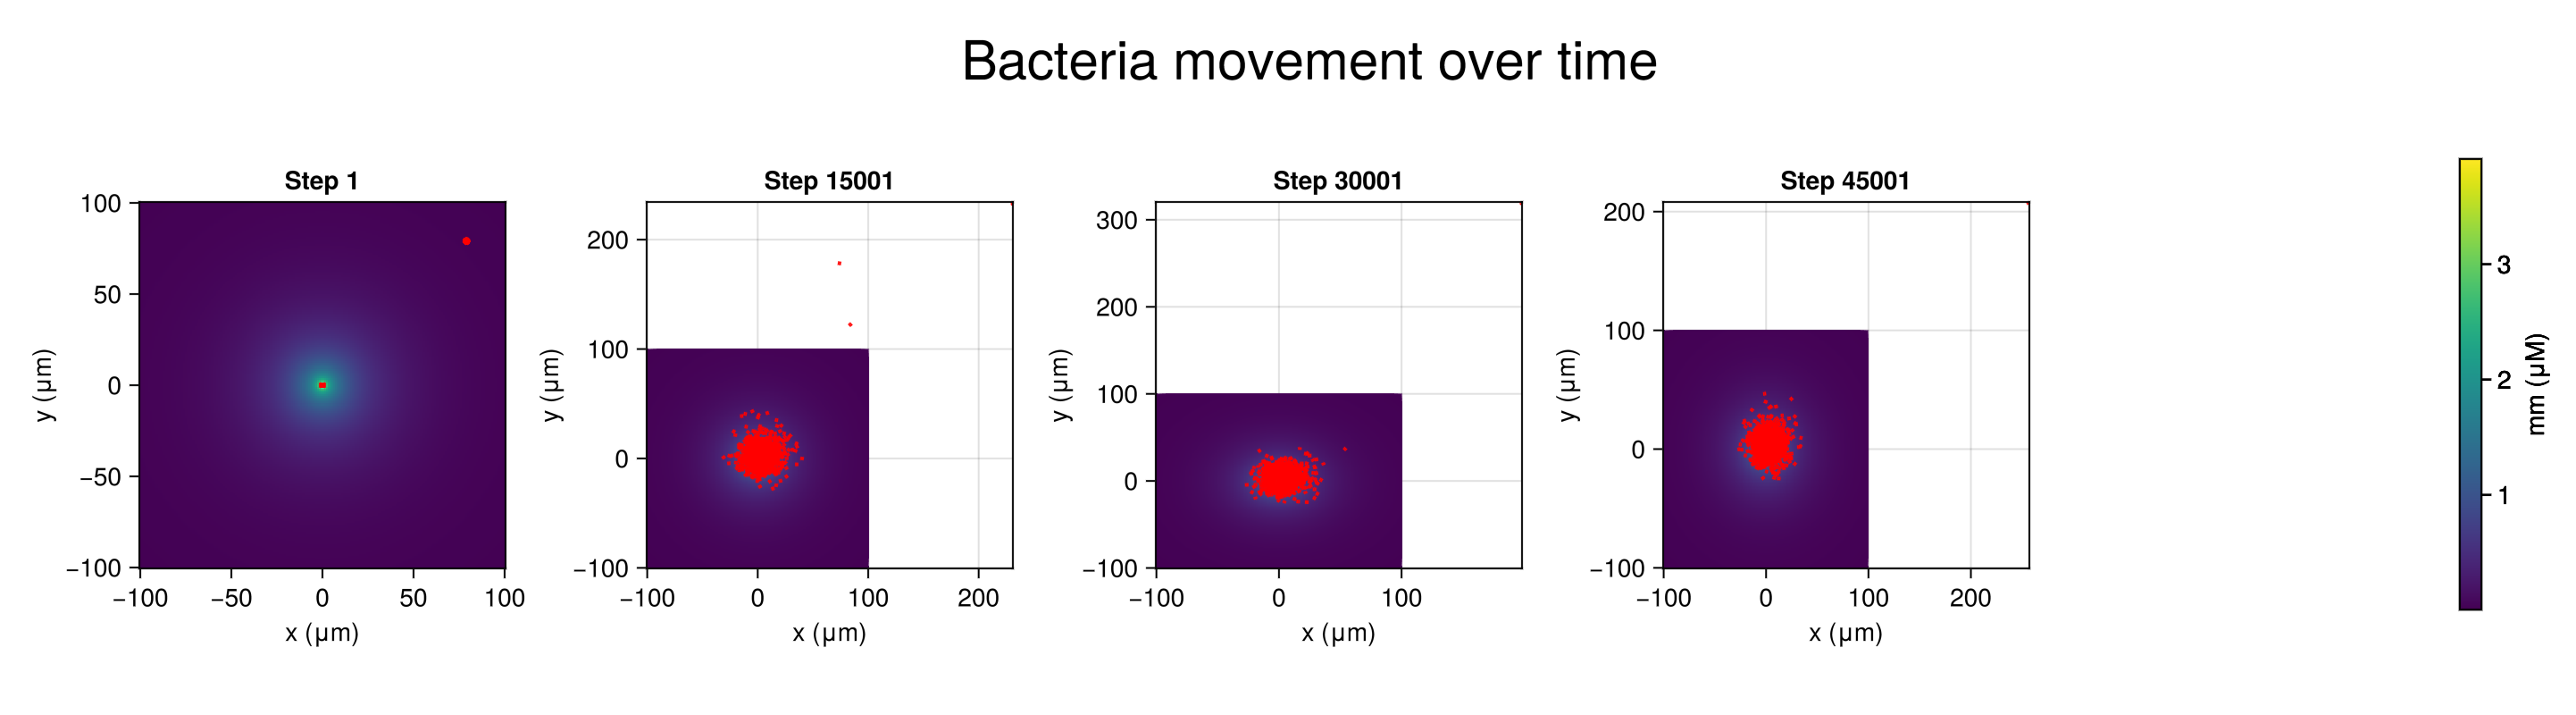

GLMakie.Screen(...)

In [7]:
fig2 = Figure(size=(2100,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

xs, ys = 0.0, 0.0


len = Int(100 + 100)
# x_grid = range(com.simBox[1], com.simBox[3], length=len)
# y_grid = range(com.simBox[2], com.simBox[4], length=len)
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(10 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

jldopen("fsb_lambda_1_1.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
        Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

    end
end
# sideinfo = Label(fig2[2, 1:5], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)

In [48]:
save("Plots/Fixed_source_model/positions_b_$(com.simBox[3] - com.simBox[1])_tm30.0.png", fig2)

In [12]:

file = jldopen("fsb_lambda_1_1.jld2", "r")

# Access the "meta" group
meta_group = file["meta"]

# Read individual variables
N_val = meta_group["N"]
NMedium_val = meta_group["NMedium"]
steps_val = meta_group["steps"]
DMedium_val = meta_group["DMedium"]
delta_val = meta_group["delta"]

# Display them
println("N: ", N_val)
println("NMedium: ", NMedium_val)
println("Steps: ", steps_val)
println("DMedium: ", DMedium_val)
println("Delta: ", delta_val)

# Close the file
close(file)

N: 1001
NMedium: [200, 200]
Steps: 60000
DMedium: [10.0]
Delta: [0.01]


In [46]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source")

mean_dist = Float64[] 
std_dist = Float64[]

jldopen("fsb_lambda_0.25_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists = abs.(sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2))

        push!(mean_dist, mean(dists))
        push!(std_dist, std(dists))

    end

    std_dist_1 = std_dist ./ sqrt(com.N - 1)

    lines!(ax1, (1:steps)*0.01, mean_dist)
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation")  #Standard deviation

    # lines!(ax1, log.((1:steps)*0.01), log.(mean_dist))
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation")  #Standard deviation
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist, mean_dist .+ std_dist, color=(:yellow, 0.2), label = "Standard error")      #Standard error

    # errorbars!(ax1, (1:steps)*0.01, mean_dist, std_dist, label = "Std deviation", color = (:red, 0.2), whiskerwidth = 0.1)
end
# sideinfo = Label(fig3[2, 1], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
# supertitle  = Label(fig3[0, :], "Distance to source", fontsize = 30)
# axislegend(ax1, position =:rt)
display(fig3)

GLMakie.Screen(...)

In [18]:
save("Plots/Fixed_source_model/bessel_21_30000_dist.png", fig3)

# Trajectoria

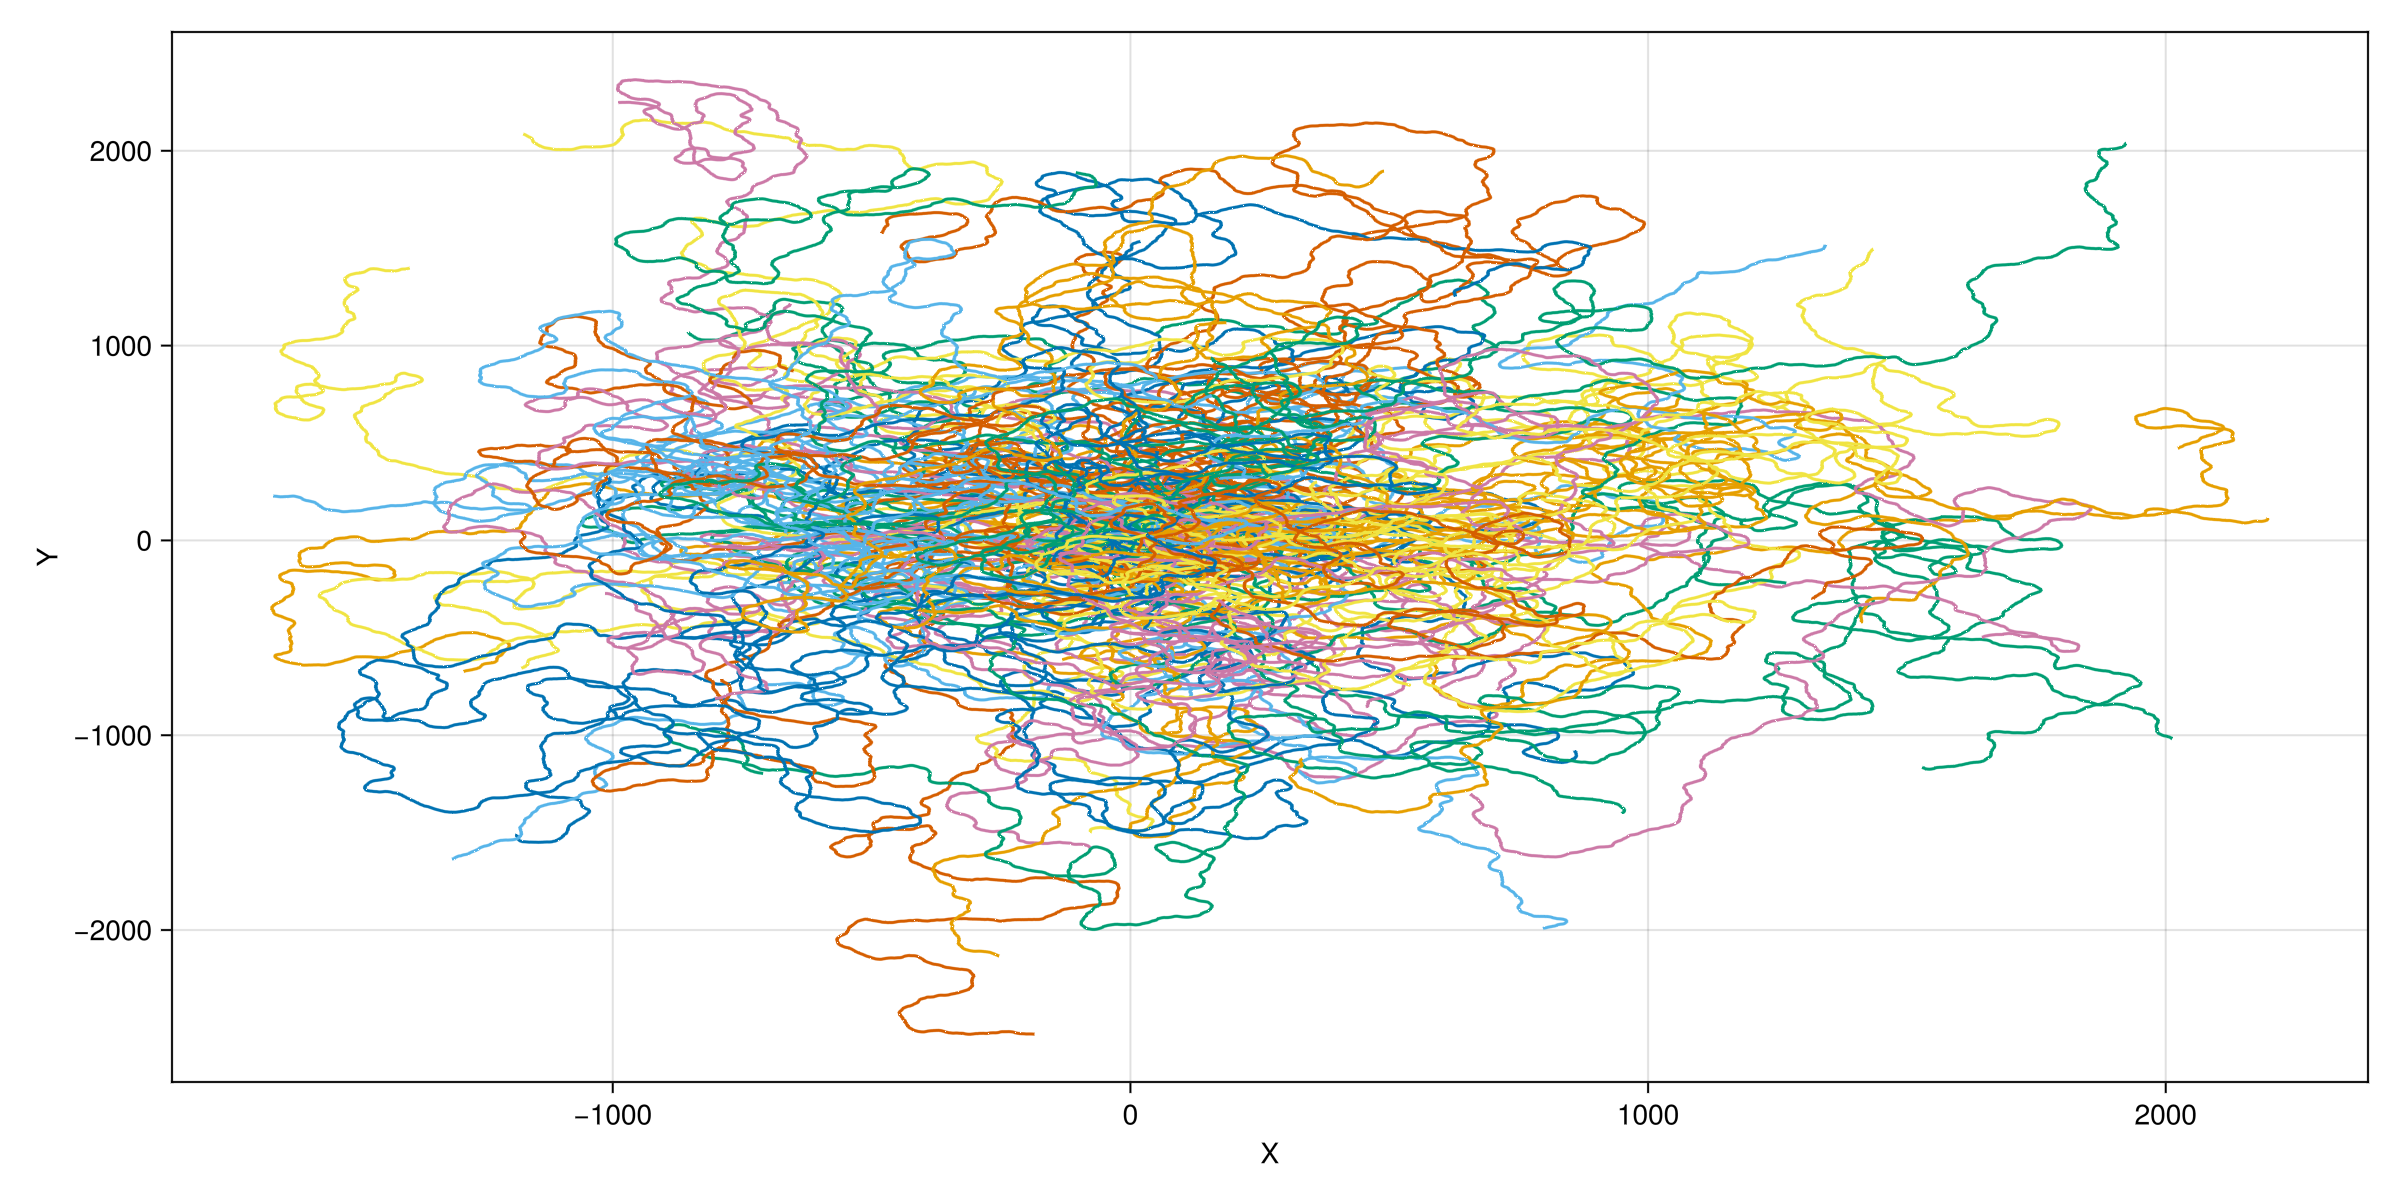

GLMakie.Screen(...)

In [4]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="X", ylabel="Y")


steps = 60000

jldopen("fsb_lambda_1.0_1.jld2", "r") do file 
    for agent in 2:100
        x = Float64[] 
        y = Float64[]

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            push!(x, x_1)
            push!(y, y_1)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(x, y)
        
    end

end
display(fig3)

# X,Y individual cells

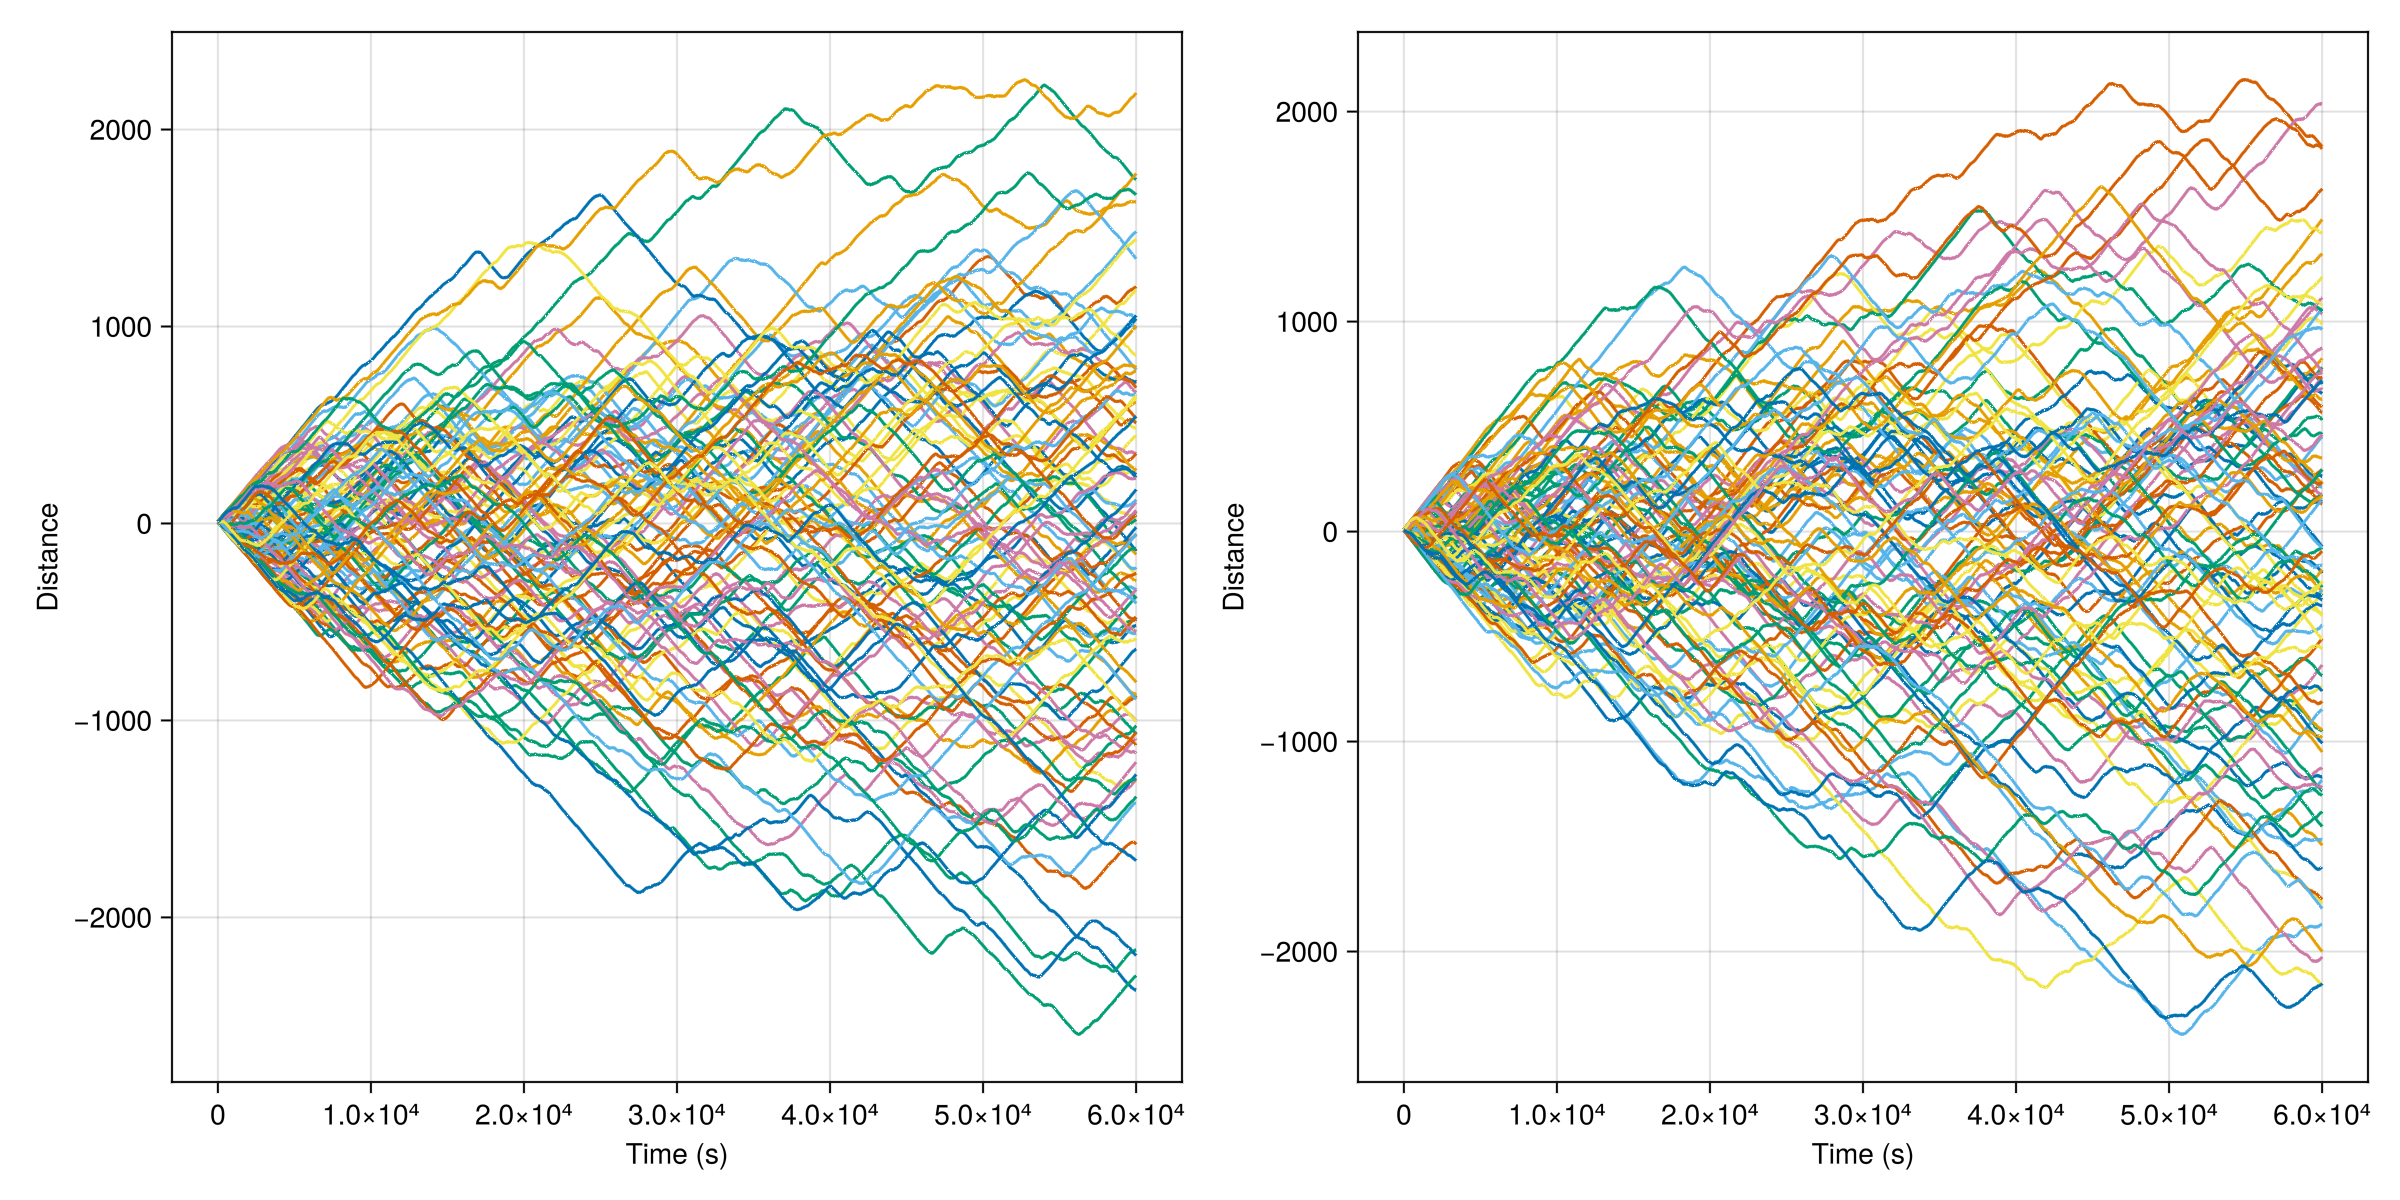

GLMakie.Screen(...)

In [5]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Distance")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Distance")



steps = 60000

jldopen("fsb_lambda_0.25_1.jld2", "r") do file 
    for agent in 2:100
        x = Float64[] 
        y = Float64[]

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = g["x"][1]
            ys = g["y"][1]

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            # dist = abs(sqrt((x_1 - xs)^2 + (y_1 - ys)^2))
            dist = x_1 - xs
            dist_2 = y_1 - ys

            push!(x, dist)
            push!(y, dist_2)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(ax1, 1:steps, x)
        lines!(ax2, 1:steps, y)
        
    end

end
display(fig3)

# X, Y Mean

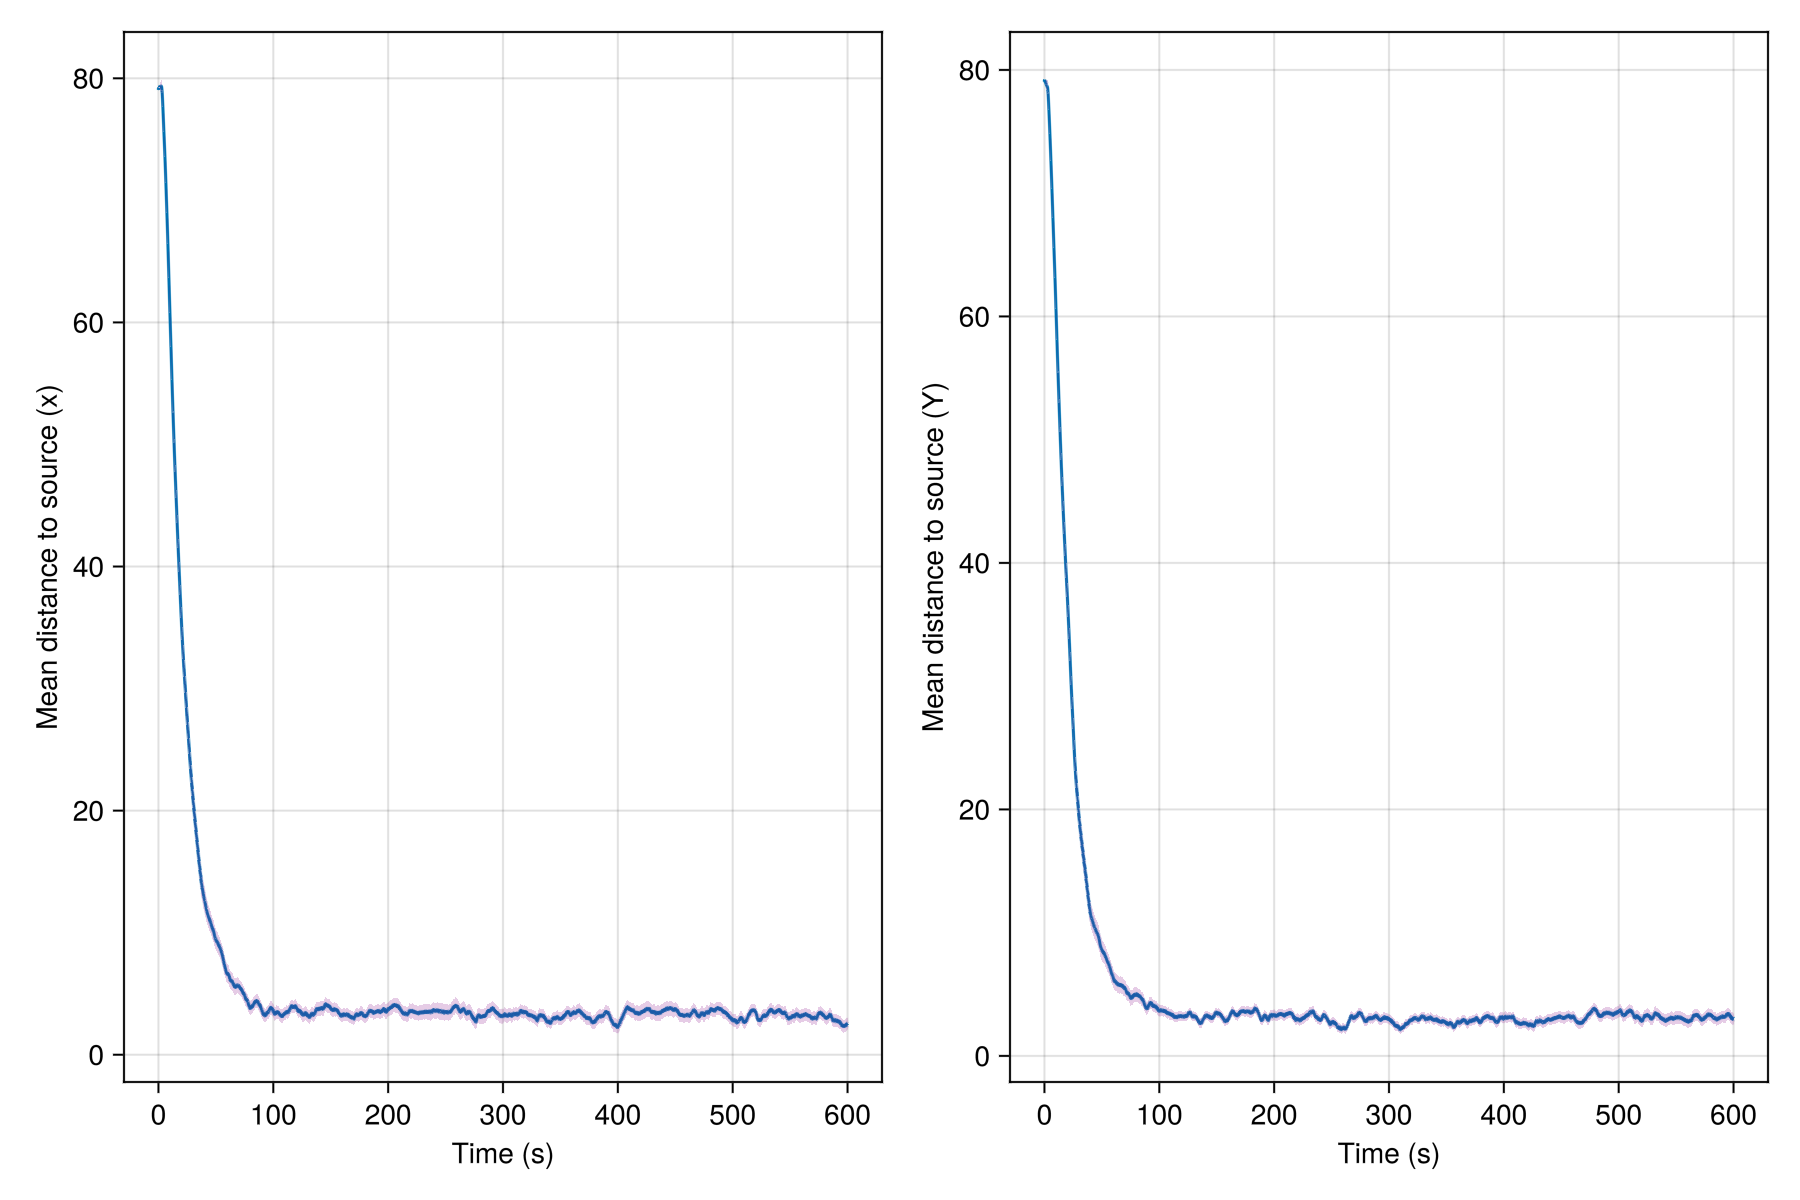

GLMakie.Screen(...)

In [24]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")

mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_omega_0.25_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(std_dist_x, std(dists_x))
        push!(mean_dist_y, mean(dists_y))
        push!(std_dist_y, std(dists_y))

    end

    std_X = std_dist_x ./ sqrt(com.N - 1)
    std_Y = std_dist_y ./ sqrt(com.N - 1)

    lines!(ax1, (1:steps)*0.01, mean_dist_x)
    band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.2), label = "Standard deviation")
    
    lines!(ax2, (1:steps)*0.01, mean_dist_y)
    band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.2), label = "Standard deviation") 
    #Standard deviation

    # lines!(ax1, log.((1:steps)*0.01), log.(mean_dist))
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation")  #Standard deviation
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist, mean_dist .+ std_dist, color=(:yellow, 0.2), label = "Standard error")      #Standard error

    # errorbars!(ax1, (1:steps)*0.01, mean_dist, std_dist, label = "Std deviation", color = (:red, 0.2), whiskerwidth = 0.1)
end
# sideinfo = Label(fig3[2, 1], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
# supertitle  = Label(fig3[0, :], "Distance to source", fontsize = 30)
# axislegend(ax1, position =:rt)
display(fig3)

# Exponential fit

In [ ]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
xlims!(0,100)


mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_lambda_0.25_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(std_dist_x, std(dists_x))
        push!(mean_dist_y, mean(dists_y))
        push!(std_dist_y, std(dists_y))

    end

    std_X = std_dist_x ./ sqrt(com.N - 1)
    std_Y = std_dist_y ./ sqrt(com.N - 1)

    # lines!(ax1, (1:steps)*0.01, log.(abs.(mean_dist_x)))
    # # band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.2), label = "Standard deviation")
    
    # lines!(ax2, (1:steps)*0.01, log.(5 .+(mean_dist_y)))
    # band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.2), label = "Standard deviation") 

    # Define the exponential model function
    exp_model(t, p) = p[1] * exp.(-p[2] .* t) .+ p[3]  # p = [A, λ, C]

    # Time vector (you're already computing this)
    time_vec = (1:steps) * 0.01

    # Fit for X distance
    initial_guess_x = [1.0, 0.01, 4.2]  # [A, λ, C] - adjust based on your data
    fit_x = curve_fit(exp_model, time_vec, mean_dist_x, initial_guess_x)
    params_x = fit_x.param  # Extract fitted parameters

    # Fit for Y distance  
    initial_guess_y = [1.0, 0.01, 4.2]
    fit_y = curve_fit(exp_model, time_vec, mean_dist_y, initial_guess_y)
    params_y = fit_y.param

    # Extract fitted values
    fitted_x = exp_model(time_vec, params_x)
    fitted_y = exp_model(time_vec, params_y)

    # Plot original data AND fitted curves
    scatterlines!(ax1, time_vec, log.(5 .+(mean_dist_x)), color=:blue, markersize=5, label="Data")
    # scatterlines!(ax1, time_vec, log.(5 .+(fitted_x)), color=:red, markersize=5, linestyle=:dash, label="Exponential fit")
    xlims!(ax1, 0,100)

    scatterlines!(ax2, time_vec, log.(5 .+ mean_dist_y), color=:blue, markersize=5, label="Data")
    # lines!(ax2, time_vec, log.(5 .+ fitted_y), color=:red, linestyle=:dash, label="Exponential fit")
    xlims!(ax2, 0,100)

    axislegend(ax1, position=:rt)
    axislegend(ax2, position=:rt)

    # R² value
    residuals_x = mean_dist_x .- fitted_x
    ss_res = sum(residuals_x.^2)
    ss_tot = sum((mean_dist_x .- mean(mean_dist_x)).^2)
    r_squared_x = 1 - (ss_res / ss_tot)

    println("X fit R² = $r_squared_x")
    println("Fitted parameters X: A=$(params_x[1]), λ=$(params_x[2]), C=$(params_x[3])")

    # R² value
    residuals_y = mean_dist_y .- fitted_y
    ss_res_y = sum(residuals_x.^2)
    ss_tot_y = sum((mean_dist_y .- mean(mean_dist_y)).^2)
    r_squared_y = 1 - (ss_res_y / ss_tot_y)

    println("Y fit R² = $r_squared_y")
    println("Fitted parameters Y: A=$(params_y[1]), λ=$(params_y[2]), C=$(params_y[3])")

end

display(fig3)

In [60]:
save("Plots/Fixed_source_model/fsb_initial_expofit.png", fig3)

# Linear fit log

In [65]:
using LinearAlgebra, Statistics, GLMakie, JLD2, Printf

steps = 60000
mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_lambda_0.25_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(mean_dist_y, mean(dists_y))

    end
end
# --- 1. LOAD YOUR DATA (from previous context) ---
# Assuming you have: mean_dist_x, mean_dist_y, time_vec

# Use absolute distances (in case of negative values)
data_x = abs.(mean_dist_x)
data_y = abs.(mean_dist_y)

# Log-transform the data
log_data_x = log.(data_x)
log_data_y = log.(data_y)

time_vec = (1:steps) * 0.01
# --- 2. AUTOMATIC DESCENT DETECTION ---
# We'll use the derivative (slope) to find the linear region

function find_linear_region(time_vec, data, log_data; 
                           min_slope=-0.1, max_slope=-0.001, 
                           min_points=20)
    """
    Automatically finds the linear descent region by:
    1. Computing local slopes (derivatives)
    2. Finding where slope is consistently negative and linear
    3. Excluding plateau and equilibrium regions
    """
    
    n = length(data)
    
    # Calculate local slopes using finite differences
    slopes = zeros(n-1)
    for i in 1:(n-1)
        slopes[i] = (log_data[i+1] - log_data[i]) / (time_vec[i+1] - time_vec[i])
    end
    
    # Find where slope is in the "descent range" (negative but not too steep)
    descent_mask = (slopes .< max_slope) .& (slopes .> min_slope)
    
    # Find contiguous regions of descent
    regions = []
    start_idx = nothing
    
    for i in 1:length(descent_mask)
        if descent_mask[i] && isnothing(start_idx)
            start_idx = i
        elseif !descent_mask[i] && !isnothing(start_idx)
            end_idx = i - 1
            if (end_idx - start_idx) >= min_points
                push!(regions, (start_idx, end_idx))
            end
            start_idx = nothing
        end
    end
    
    # If we ended in a descent region, close it
    if !isnothing(start_idx) && (length(descent_mask) - start_idx) >= min_points
        push!(regions, (start_idx, length(descent_mask)))
    end
    
    # Return the longest descent region (usually the main one)
    if isempty(regions)
        println("⚠️  No clear descent region found. Using manual fallback.")
        # Fallback: use middle 50% of data
        start_idx = div(n, 4)
        end_idx = div(3*n, 4)
        return start_idx, end_idx
    else
        # Find longest region
        longest_region = reduce((a, b) -> (last(a)-first(a) > last(b)-first(b)) ? a : b, regions)
        println("📏  Found descent region: steps $(longest_region[1]) to $(longest_region[2])")
        return longest_region[1], longest_region[2] + 1  # +1 because slopes is n-1
    end
end

# Detect linear regions for X and Y
start_x, end_x = find_linear_region(time_vec, data_x, log_data_x)
start_y, end_y = find_linear_region(time_vec, data_y, log_data_y)

# --- 3. PERFORM LINEAR FIT ON DESCENT REGION ---
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

# Fit X data
slope_x, intercept_x = linear_fit(time_vec[start_x:end_x], log_data_x[start_x:end_x])
lambda_x = -slope_x  # λ = -slope

# Fit Y data  
slope_y, intercept_y = linear_fit(time_vec[start_y:end_y], log_data_y[start_y:end_y])
lambda_y = -slope_y

println("📊 LINEAR FIT RESULTS:")
println("   X: λ = $(round(lambda_x, digits=4)) s⁻¹ (slope = $(round(slope_x, digits=4)))")
println("   Y: λ = $(round(lambda_y, digits=4)) s⁻¹ (slope = $(round(slope_y, digits=4)))")

# --- 4. PLOT RESULTS ---
fig_linear = Figure(size=(900, 600))

# Plot X
ax1 = Axis(fig_linear[1, 1], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax1, time_vec, log_data_x, color=:blue, markersize=3, label="Data")
lines!(ax1, time_vec[start_x:end_x], log_data_x[start_x:end_x], 
       color=:green, linewidth=2, label="Fitted region")
# Plot fitted line
fitted_line_x = [intercept_x + slope_x * t for t in time_vec]
lines!(ax1, time_vec, fitted_line_x, color=:red, linestyle=:dash, 
       linewidth=2, label="Linear fit (λ=$(round(lambda_x, digits=3)))")
ax1.title = "X-Distance (Log Scale)"
axislegend(ax1, position=:rt)
# xlims!(ax1, 0, 90)
# ylims!(ax1, 0, 5)


# Plot Y
ax2 = Axis(fig_linear[1, 2], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax2, time_vec, log_data_y, color=:blue, markersize=3, label="Data")
lines!(ax2, time_vec[start_y:end_y], log_data_y[start_y:end_y], 
       color=:green, linewidth=2, label="Fitted region")
fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
lines!(ax2, time_vec, fitted_line_y, color=:red, linestyle=:dash, 
       linewidth=2, label="Linear fit (λ=$(round(lambda_y, digits=3)))")
ax2.title = "Y-Distance (Log Scale)"
axislegend(ax2, position=:rt)
# xlims!(ax2, 0, 90)
# ylims!(ax2, 0, 5)


display(fig_linear)

# --- 5. COMPARE WITH EXPONENTIAL FIT ---
# println("\n📈 COMPARISON:")
# println("   Linear fit λ_x: $(round(lambda_x, digits=4)) vs Exp fit λ_x: $(round(params_x[2], digits=4))")
# println("   Linear fit λ_y: $(round(lambda_y, digits=4)) vs Exp fit λ_y: $(round(params_y[2], digits=4))")

📏  Found descent region: steps 13167 to 15823
📏  Found descent region: steps 54187 to 58447
📊 LINEAR FIT RESULTS:
   X: λ = 0.0477 s⁻¹ (slope = -0.0477)
   Y: λ = 0.0089 s⁻¹ (slope = -0.0089)


GLMakie.Screen(...)

In [26]:
save("Plots/Fixed_source_model/lineal_fit_log_test.png", fig_linear)

# Lineal fit normal (no log)

In [22]:
using LinearAlgebra, Statistics, GLMakie, JLD2, Printf

# --- 0. SETUP & DATA LOADING ---
steps = 60000
mean_dist_x = Float64[] 
mean_dist_y = Float64[] 

# Load data from file
# Ensure "fsb_initial_l.jld2" and "com.N" are available in your environment
jldopen("fsb_initial_l.jld2", "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        ys = g["y"][1]
        other_x = g["x"][2:com.N]
        other_y = g["y"][2:com.N]
        push!(mean_dist_x, mean(other_x .- xs))
        push!(mean_dist_y, mean(other_y .- ys))
    end
end

time_vec = (1:steps) * 0.01
data_x = abs.(mean_dist_x)
data_y = abs.(mean_dist_y)

# --- 1. AUTOMATIC DESCENT DETECTION ---
function find_linear_descent_region(time_vec, data; 
                                   min_slope=-10.0, max_slope=-0.05, 
                                   min_points=50)
    n = length(data)
    
    # Calculate local slopes (velocity) on raw data
    slopes = zeros(n-1)
    for i in 1:(n-1)
        slopes[i] = (data[i+1] - data[i]) / (time_vec[i+1] - time_vec[i])
    end
    
    # Mask: Look for negative slopes (descent)
    # We exclude very flat regions (equilibrium) and extremely steep spikes (noise)
    descent_mask = (slopes .< max_slope) .& (slopes .> min_slope)
    
    # Find contiguous regions
    regions = []
    start_idx = nothing
    
    for i in 1:length(descent_mask)
        if descent_mask[i] && isnothing(start_idx)
            start_idx = i
        elseif !descent_mask[i] && !isnothing(start_idx)
            end_idx = i - 1
            if (end_idx - start_idx) >= min_points
                push!(regions, (start_idx, end_idx))
            end
            start_idx = nothing
        end
    end
    
    # Close final region if needed
    if !isnothing(start_idx) && (length(descent_mask) - start_idx) >= min_points
        push!(regions, (start_idx, length(descent_mask)))
    end
    
    if isempty(regions)
        println("⚠️  No clear descent region found. Using fallback (5% to 30% of time).")
        start_idx = div(n, 20)
        end_idx = div(3*n, 10)
        return start_idx, end_idx
    else
        # Pick the longest continuous region (usually the main descent)
        longest_region = reduce((a, b) -> (last(a)-first(a) > last(b)-first(b)) ? a : b, regions)
        
        t_start = time_vec[longest_region[1]]
        t_end = time_vec[longest_region[2]]
        println("📏  Found descent region: $(round(t_start, digits=1))s to $(round(t_end, digits=1))s")
        
        return longest_region[1], longest_region[2] + 1
    end
end

# Detect regions for X and Y
start_x, end_x = find_linear_descent_region(time_vec, data_x)
start_y, end_y = find_linear_descent_region(time_vec, data_y)

# --- 2. PERFORM LINEAR FIT & CALCULATE LAMBDA ---
function calculate_lambda_from_raw_fit(t, data)
    # Linear Fit: y = slope * t + intercept
    n = length(t)
    sum_t = sum(t)
    sum_y = sum(data)
    sum_ty = sum(t .* data)
    sum_t2 = sum(t.^2)
    
    slope = (n * sum_ty - sum_t * sum_y) / (n * sum_t2 - sum_t^2)
    intercept = (sum_y - slope * sum_t) / n
    
    # Calculate Mean Distance in this region
    mean_dist = sum(data) / n
    
    # Calculate Lambda: λ = -slope / mean_distance
    # Physics: dx/dt = -λ * x  =>  slope = -λ * mean_dist
    lambda_val = -slope / mean_dist
    
    return slope, intercept, mean_dist, lambda_val
end

# Calculate for X
slope_x, intercept_x, mean_x, lambda_x = calculate_lambda_from_raw_fit(
    time_vec[start_x:end_x], 
    data_x[start_x:end_x]
)

# Calculate for Y
slope_y, intercept_y, mean_y, lambda_y = calculate_lambda_from_raw_fit(
    time_vec[start_y:end_y], 
    data_y[start_y:end_y]
)

println("\n📊 LINEAR FIT RESULTS (Raw Data → Lambda):")
println("   X: Slope = $(round(slope_x, digits=3)) μm/s")
println("      Mean Dist = $(round(mean_x, digits=2)) μm")
println("      ➡️  λ (Decay Rate) = $(round(lambda_x, digits=4)) s⁻¹")
println("\n   Y: Slope = $(round(slope_y, digits=3)) μm/s")
println("      Mean Dist = $(round(mean_y, digits=2)) μm")
println("      ➡️  λ (Decay Rate) = $(round(lambda_y, digits=4)) s⁻¹")

# --- 3. PLOT RESULTS ---
GLMakie.activate!()
fig = Figure(size=(900, 600))

# Plot X
ax1 = Axis(fig[1, 1], xlabel="Time (s)", ylabel="Mean Distance to Source (μm)")
scatter!(ax1, time_vec, data_x, color=:blue, markersize=2, label="Data", alpha=0.5)
lines!(ax1, time_vec[start_x:end_x], data_x[start_x:end_x], 
       color=:green, linewidth=2, label="Fitted Region")

# Plot fitted line
fitted_line_x = [intercept_x + slope_x * t for t in time_vec]
lines!(ax1, time_vec, fitted_line_x, color=:red, linestyle=:dash, linewidth=2, 
       label="Linear Fit (λ=$(round(lambda_x, digits=3)))")

ax1.title = "X-Distance (Raw Fit → λ)"
axislegend(ax1, position=:rt)
xlims!(ax1, 0, 200) # Zoom to see the fit clearly
ylims!(ax1, 0, 100)


# Plot Y
ax2 = Axis(fig[1, 2], xlabel="Time (s)", ylabel="Mean Distance to Source (μm)")
scatter!(ax2, time_vec, data_y, color=:blue, markersize=2, label="Data", alpha=0.5)
lines!(ax2, time_vec[start_y:end_y], data_y[start_y:end_y], 
       color=:green, linewidth=2, label="Fitted Region")

fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
lines!(ax2, time_vec, fitted_line_y, color=:red, linestyle=:dash, linewidth=2, 
       label="Linear Fit (λ=$(round(lambda_y, digits=3)))")

ax2.title = "Y-Distance (Raw Fit → λ)"
axislegend(ax2, position=:rt)
xlims!(ax2, 0, 200)
ylims!(ax2, 0, 100)

display(fig)

println("\n💡 Interpretation:")
println("   This λ is derived from the ratio of Velocity/Distance during the descent.")
println("   It represents the effective 'spring constant' of the chemotactic force.")

📏  Found descent region: 2.5s to 52.6s
📏  Found descent region: 2.7s to 54.9s

📊 LINEAR FIT RESULTS (Raw Data → Lambda):
   X: Slope = -1.544 μm/s
      Mean Dist = 27.7 μm
      ➡️  λ (Decay Rate) = 0.0557 s⁻¹

   Y: Slope = -1.478 μm/s
      Mean Dist = 26.26 μm
      ➡️  λ (Decay Rate) = 0.0563 s⁻¹

💡 Interpretation:
   This λ is derived from the ratio of Velocity/Distance during the descent.
   It represents the effective 'spring constant' of the chemotactic force.


In [24]:
save("Plots/Fixed_source_model/linear_fit_test.png", fig)

# Histograms with gaussian fit from eq

Equilibrium starts at t ≈ 92.97 s
Analyzing from step 9298 to 60000
📈  X-Distance Distribution: Mean = 2.887, σ = 11.52
📈  Y-Distance Distribution: Mean = 2.933, σ = 12.662


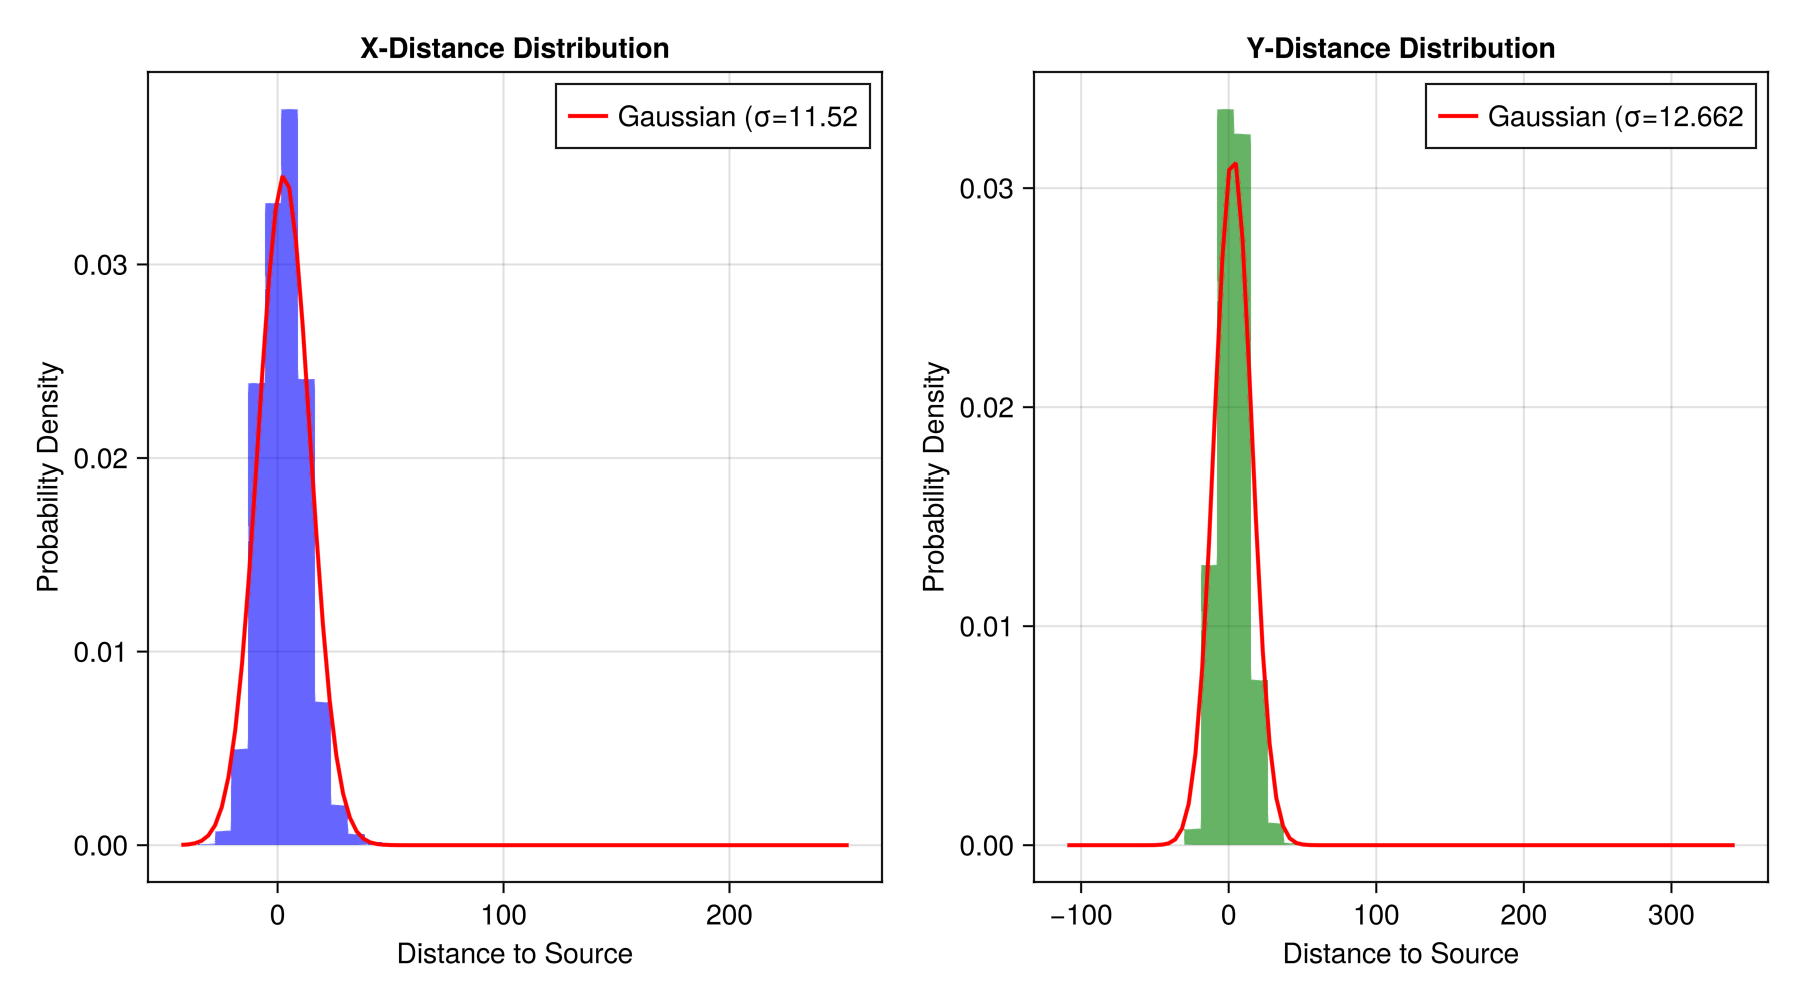

GLMakie.Screen(...)

In [10]:
using Distributions
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")

mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

paramsX = []
paramsY = []

steps = 60000

jldopen("fsb_lambda_0.25_2.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(std_dist_x, std(dists_x))
        push!(mean_dist_y, mean(dists_y))
        push!(std_dist_y, std(dists_y))

    end

    std_X = std_dist_x ./ sqrt(com.N - 1)
    std_Y = std_dist_y ./ sqrt(com.N - 1)

    # Define the exponential model function
    exp_model(t, p) = p[1] * exp.(-p[2] .* t) .+ p[3]  # p = [A, λ, C]

    # Time vector (you're already computing this)
    time_vec = (1:steps) * 0.01

    # Fit for X distance
    initial_guess_x = [1.0, 0.01, 4.2]  # [A, λ, C] - adjust based on your data
    fit_x = curve_fit(exp_model, time_vec, mean_dist_x, initial_guess_x)
    params_x = fit_x.param  # Extract fitted parameters

    # Fit for Y distance  
    initial_guess_y = [1.0, 0.01, 4.2]
    fit_y = curve_fit(exp_model, time_vec, mean_dist_y, initial_guess_y)
    params_y = fit_y.param

    # Extract fitted values
    fitted_x = exp_model(time_vec, params_x)
    fitted_y = exp_model(time_vec, params_y)

    push!(paramsX, params_x)
    push!(paramsY, params_y)
end

paramsX_1 = paramsX[1]

lambda_fit = paramsX_1[2] 
tau = 1.0 / lambda_fit
t_equilibrium = 5.0 * tau
time_vec = (1:steps) * 0.01

println("Equilibrium starts at t ≈ $(round(t_equilibrium, digits=2)) s")

step_eq = findfirst(t -> t >= t_equilibrium, (1:steps)*0.01)
if isnothing(step_eq)
    step_eq = steps
    println("Warning: Using all data")
else
    println("Analyzing from step $step_eq to $steps")
end

# --- 3. EXTRACT DATA ---
equil_dist_x = Float64[]
equil_dist_y = Float64[]

jldopen("fsb_lambda_0.25_2.jld2", "r") do file 
    for step in step_eq:steps
        g = file[@sprintf("step_%06d", step)]
        
        xs_src = g["x"][1]
        ys_src = g["y"][1]
        
        agents_x = g["x"][2:com.N] 
        agents_y = g["y"][2:com.N]
        
        dists_x = agents_x .- xs_src
        dists_y = agents_y .- ys_src
        
        append!(equil_dist_x, dists_x)
        append!(equil_dist_y, dists_y)
    end
end


# --- 4. MANUAL GAUSSIAN FIT FUNCTION ---
# This calculates μ and σ manually, then builds the Gaussian curve
function gaussian_pdf(x, μ, σ)
    return (1.0 / (σ * sqrt(2π))) * exp(-0.5 * ((x - μ) / σ)^2)
end

function plot_hist_with_manual_fit!(ax, data, label_color, title_text)
    # Calculate statistics manually
    μ = mean(data)
    σ = std(data)
    
    println("📈  $title_text: Mean = $(round(μ, digits=3)), σ = $(round(σ, digits=3))")
    
    # Plot Histogram
    hist!(ax, data, bins=40, color=(label_color, 0.6), 
          normalization=:pdf)
    
    # Generate Gaussian curve manually
    x_range = range(minimum(data), maximum(data), length=100)
    y_gauss = [gaussian_pdf(x, μ, σ) for x in x_range]
    
    lines!(ax, x_range, y_gauss, color=:red, linewidth=2, 
           label="Gaussian (σ=$(round(σ, digits=3))")
    
    axislegend(ax, position=:rt)
    ax.title = title_text
    ax.xlabel = "Distance to Source"
    ax.ylabel = "Probability Density"
    # xlims!(ax, -50, 50)
end

# --- 5. PLOT ---
fig_hist = Figure(size=(900, 500))

ax_x = Axis(fig_hist[1, 1])
plot_hist_with_manual_fit!(ax_x, equil_dist_x, :blue, "X-Distance Distribution")

ax_y = Axis(fig_hist[1, 2])
plot_hist_with_manual_fit!(ax_y, equil_dist_y, :green, "Y-Distance Distribution")

display(fig_hist)

# # --- 6. AUTOCORRELATION ---
# agent_id = 2
# traj_x = Float64[]

# jldopen("fsb_initial_l.jld2", "r") do file 
#     for step in step_eq:steps
#         g = file[@sprintf("step_%06d", step)]
#         xs_src = g["x"][1]
#         push!(traj_x, g["x"][agent_id] - xs_src)
#     end
# end

# max_lag = min(50, length(traj_x) - 1)
# acf_vals = [cor(traj_x[1:end-l], traj_x[1+l:end]) for l in 0:max_lag]

# fig_acf = Figure(size=(600, 400))
# ax_acf = Axis(fig_acf[1, 1], title="Autocorrelation (X)", xlabel="Lag", ylabel="Correlation")
# lines!(ax_acf, 0:max_lag, acf_vals, color=:purple, linewidth=2)
# hlines!(ax_acf, [0.0], color=:black, linestyle=:dash)
# display(fig_acf)

In [12]:
save("Plots/Fixed_source_model/equilibrium_gaussian_fit_lambda_0.25_1.png", fig_hist)

# Base

In [ ]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="X distance", ylabel="Distribution")
ax2 = Axis(fig3[1,2], xlabel="Y distance", ylabel="Distribution")

mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_initial_l.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(std_dist_x, std(dists_x))
        push!(mean_dist_y, mean(dists_y))
        push!(std_dist_y, std(dists_y))

    end

    std_X = std_dist_x ./ sqrt(com.N - 1)
    std_Y = std_dist_y ./ sqrt(com.N - 1)

    lines!(ax1, (1:steps)*0.01, mean_dist_x)
    band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.2), label = "Standard deviation")
    
    lines!(ax2, (1:steps)*0.01, mean_dist_y)
    band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.2), label = "Standard deviation") 

end

display(fig3)

# Ratios


In [21]:
l = sqrt(com.DMedium[1]/com.delta[1])
# τs = l^2 / (2*com.Ds[1])
τv = l / com.v[1]
τc = l^2 / com.DMedium[1]

ratio_lambda = com.τm[1] / τv
# ratio_gamma = com.τm[1] / τs
ratio_omega = τv / τc

println("lambda: ", ratio_lambda, " omega: ", ratio_omega)


lambda: 0.31622776601683794 omega: 0.03162277660168379


In [42]:
lambdas = ["0.25", "0.5", "0.75", "1.0"]
# lambdas = ["0.25", "05", "0.75", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
n_trials = 3

df_lambda = DataFrame(
    lambda = String[],
    trial = Int[],
    mean_r = Float64[],
    mean_x = Float64[],
    mean_y = Float64[],
    Dc = Float64[],
    delta = Float64[],
    l = Float64[],
    tm = Float64[],
    v = Float64[]
)

steps = 60000
for λ in lambdas
    for trial in 1:n_trials

        filename = @sprintf("fsb_lambda_%s_%d.jld2", λ, trial)

        jldopen(filename, "r") do file

            gdata = file[@sprintf("step_%06d", steps)]

            x = gdata["x"]
            y = gdata["y"]

            xs = x[1]
            ys = y[1]

            dist = abs.(sqrt.((x[2:end] .- xs).^2 .+ (y[2:end] .- ys).^2))
            dist_x = x[2:end] .- xs
            dist_y = y[2:end] .- ys

            mean_r = mean(dist)
            mean_x = mean(dist_x)
            mean_y = mean(dist_y)

            Dc = gdata["DMedium"][1]
            delta_val = gdata["delta"][1]
            tm_val = 1
            v_val = 10
            l = sqrt(Dc / delta_val)


            push!(df_lambda, (
                λ,
                trial,
                mean_r,
                mean_x,
                mean_y,
                Dc,
                delta_val,
                l,
                tm_val,
                v_val
            ))
        end
    end
end

df_lambda

Row,lambda,trial,mean_r,mean_x,mean_y,Dc,delta,l,tm,v
,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.25,1,617.23,-21.7485,16.729,2.5,0.04,7.90569,1.0,10.0
2,0.25,2,614.032,0.92335,-10.1727,2.5,0.04,7.90569,1.0,10.0
3,0.25,3,615.091,18.4632,1.9131,2.5,0.04,7.90569,1.0,10.0
4,0.5,1,624.231,8.92954,22.7356,5.0,0.02,15.8114,1.0,10.0
5,0.5,2,619.976,29.5539,3.68885,5.0,0.02,15.8114,1.0,10.0
6,0.5,3,599.73,18.8808,-11.7095,5.0,0.02,15.8114,1.0,10.0
7,0.75,1,602.253,14.5265,10.5647,7.5,0.0133333,23.7171,1.0,10.0
8,0.75,2,615.548,2.91988,6.71398,7.5,0.0133333,23.7171,1.0,10.0
9,0.75,3,618.704,15.5576,11.2323,7.5,0.0133333,23.7171,1.0,10.0


In [55]:
fig = Figure(size=(1200, 600))
ax1 = Axis(fig[1,1], xlabel="Lambda (n)", ylabel="<r>/l")
ax2 = Axis(fig[2,1], xlabel="Lambda (n)", ylabel="X <r>/l")
ax3 = Axis(fig[2,2], xlabel="Lambda (n)", ylabel="Y <r>/l")

r_l = Float64[] 
r_l_x = Float64[] 
r_l_y = Float64[] 
group_std = Float64[]

lambdas = [0.25, 0.5, 0.75, 1]
# lambdas = [0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

group_size = 3
n_groups = length(df_lambda.lambda) ÷ group_size

for g in 1:n_groups
    
    group_mean = Float64[]
    group_mean_x = Float64[]
    group_mean_y = Float64[]

    # files 1:3, 4:6, 7:9
    for f in ((g-1)*group_size + 1):(g*group_size)
        mean = df_lambda.mean_r[f]
        mean_x = df_lambda.mean_x[f]
        mean_y = df_lambda.mean_y[f]
        push!(group_mean, mean)
        push!(group_mean_x, mean_x)
        push!(group_mean_y, mean_y)
    end

    # mean of the 3 simulations in this group
    push!(r_l, mean(group_mean))
    push!(r_l_x, mean(group_mean_x))
    push!(r_l_y, mean(group_mean_y))
    push!(group_std, std(group_mean))

end


lines!(ax1, lambdas, r_l)
band!(ax1, lambdas, r_l .- group_std, r_l .+ group_std, color = (:blue, 0.2))
lines!(ax2, lambdas, r_l_x)
lines!(ax3, lambdas, r_l_y)


display(fig)

GLMakie.Screen(...)

In [14]:
lambdas = ["0.25", "0.5", "0.75", "1.0", "2.0"]
n_trials = 3

for λ in lambdas

    filename = @sprintf("fsb_lambda_%s_1.jld2", λ)
 
    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]

    paramsX = []
    paramsY = []

    steps = 60000

    jldopen(filename, "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = g["x"][1]
            ys = g["y"][1]

            other_x = g["x"][2:com.N]

            other_y = g["y"][2:com.N]

            dists_x = other_x .- xs
            dists_y = other_y .- ys

            push!(mean_dist_x, mean(dists_x))
            push!(std_dist_x, std(dists_x))
            push!(mean_dist_y, mean(dists_y))
            push!(std_dist_y, std(dists_y))

        end

        std_X = std_dist_x ./ sqrt(com.N - 1)
        std_Y = std_dist_y ./ sqrt(com.N - 1)

        # Define the exponential model function
        exp_model(t, p) = p[1] * exp.(-p[2] .* t) .+ p[3]  # p = [A, λ, C]

        # Time vector (you're already computing this)
        time_vec = (1:steps) * 0.01

        # Fit for X distance
        initial_guess_x = [1.0, 0.01, 4.2]  # [A, λ, C] - adjust based on your data
        fit_x = curve_fit(exp_model, time_vec, mean_dist_x, initial_guess_x)
        params_x = fit_x.param  # Extract fitted parameters

        # Fit for Y distance  
        initial_guess_y = [1.0, 0.01, 4.2]
        fit_y = curve_fit(exp_model, time_vec, mean_dist_y, initial_guess_y)
        params_y = fit_y.param

        # Extract fitted values
        fitted_x = exp_model(time_vec, params_x)
        fitted_y = exp_model(time_vec, params_y)

        push!(paramsX, params_x)
        push!(paramsY, params_y)
    end

    paramsX_1 = paramsX[1]

    lambda_fit = paramsX_1[2] 
    tau = 1.0 / lambda_fit
    t_equilibrium = 5.0 * tau
    time_vec = (1:steps) * 0.01

    println("Equilibrium starts at t ≈ $(round(t_equilibrium, digits=2)) s")

    step_eq = findfirst(t -> t >= t_equilibrium, (1:steps)*0.01)
    if isnothing(step_eq)
        step_eq = steps
        println("Warning: Using all data")
    else
        println("Analyzing from step $step_eq to $steps")
    end

    # --- 3. EXTRACT DATA ---
    equil_dist_x = Float64[]
    equil_dist_y = Float64[]

    jldopen("fsb_lambda_0.25_2.jld2", "r") do file 
        for step in step_eq:steps
            g = file[@sprintf("step_%06d", step)]
            
            xs_src = g["x"][1]
            ys_src = g["y"][1]
            
            agents_x = g["x"][2:com.N] 
            agents_y = g["y"][2:com.N]
            
            dists_x = agents_x .- xs_src
            dists_y = agents_y .- ys_src
            
            append!(equil_dist_x, dists_x)
            append!(equil_dist_y, dists_y)
        end
    end


    # --- 4. MANUAL GAUSSIAN FIT FUNCTION ---
    # This calculates μ and σ manually, then builds the Gaussian curve
    function gaussian_pdf(x, μ, σ)
        return (1.0 / (σ * sqrt(2π))) * exp(-0.5 * ((x - μ) / σ)^2)
    end

    function plot_hist_with_manual_fit!(data)
        # Calculate statistics manually
        μ = mean(data)
        σ = std(data)
        
        println("$λ, lamba, Mean = $(round(μ, digits=3)), σ = $(round(σ, digits=3))")
    end

    plot_hist_with_manual_fit!(equil_dist_x)
    plot_hist_with_manual_fit!(equil_dist_y)
end


Equilibrium starts at t ≈ 97.92 s
Analyzing from step 9792 to 60000
0.25, lamba, Mean = 2.878, σ = 11.478
0.25, lamba, Mean = 2.926, σ = 12.642
Equilibrium starts at t ≈ 95.39 s
Analyzing from step 9540 to 60000
0.5, lamba, Mean = 2.883, σ = 11.499
0.5, lamba, Mean = 2.93, σ = 12.65
Equilibrium starts at t ≈ 97.2 s
Analyzing from step 9721 to 60000
0.75, lamba, Mean = 2.879, σ = 11.484
0.75, lamba, Mean = 2.927, σ = 12.644
Equilibrium starts at t ≈ 94.3 s
Analyzing from step 9430 to 60000
1.0, lamba, Mean = 2.885, σ = 11.509
1.0, lamba, Mean = 2.932, σ = 12.655
Equilibrium starts at t ≈ 101.07 s
Analyzing from step 10107 to 60000
2.0, lamba, Mean = 2.872, σ = 11.455
2.0, lamba, Mean = 2.924, σ = 12.636


# ChatGPT pipeline

In [8]:
function safe_log(x; eps=1e-8)
    return log.(abs.(x) .+ eps)
end

function linear_fit(x, y)
    n = length(x)
    slope = (n * sum(x .* y) - sum(x) * sum(y)) / (n * sum(x.^2) - sum(x)^2)
    intercept = (sum(y) - slope * sum(x)) / n
    return slope, intercept
end

function find_log_descent_region(log_data, time_vec; window=2000)
    """
    Finds region where log(data) is approximately linear decreasing
    """
    slopes = diff(log_data) ./ diff(time_vec)

    # smooth slopes
    smooth = [mean(slopes[i:i+50]) for i in 1:(length(slopes)-50)]

    # find where slope becomes too small (approaching equilibrium)
    idx = findfirst(x -> x > -1e-3, smooth)

    if isnothing(idx)
        return 1, window
    else
        return 1, min(idx, window)
    end
end

function find_equilibrium(r)
    dr = abs.(diff(r))
    idx = findfirst(x -> x < 1e-3, dr)

    if isnothing(idx)
        return Int(0.7 * length(r))
    else
        return idx
    end
end

function analyze_simulation(filename; steps=60000, dt=0.01)

    mean_dx = Float64[]
    mean_dy = Float64[]

    # -----------------------------
    # LOAD DATA
    # -----------------------------
    jldopen(filename, "r") do file
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = g["x"][1]
            ys = g["y"][1]

            other_x = g["x"][2:end]
            other_y = g["y"][2:end]

            push!(mean_dx, mean(other_x .- xs))
            push!(mean_dy, mean(other_y .- ys))
        end
    end

    time_vec = (1:steps) .* dt

    # -----------------------------
    # RADIAL (for equilibrium detection only)
    # -----------------------------
    r = sqrt.(mean_dx.^2 .+ mean_dy.^2)

    # -----------------------------
    # LOG FIT (X and Y separately)
    # -----------------------------
    log_x = safe_log(mean_dx)
    log_y = safe_log(mean_dy)

    sx, ex = find_log_descent_region(log_x, time_vec)
    sy, ey = find_log_descent_region(log_y, time_vec)

    slope_x, _ = linear_fit(time_vec[sx:ex], log_x[sx:ex])
    slope_y, _ = linear_fit(time_vec[sy:ey], log_y[sy:ey])

    λ_x = -slope_x
    λ_y = -slope_y

    # -----------------------------
    # EQUILIBRIUM
    # -----------------------------
    eq_idx = find_equilibrium(r)

    eq_x = mean_dx[eq_idx:end]
    eq_y = mean_dy[eq_idx:end]

    μ_x = mean(eq_x)
    μ_y = mean(eq_y)

    σ_x = std(eq_x)
    σ_y = std(eq_y)

    # radial fluctuations (optional)
    r_eq = sqrt.(eq_x.^2 .+ eq_y.^2)
    σ_r = std(r_eq)

    return (
        λ_x = λ_x,
        λ_y = λ_y,
        μ_x = μ_x,
        μ_y = μ_y,
        σ_x = σ_x,
        σ_y = σ_y,
        σ_r = σ_r
    )
end

analyze_simulation (generic function with 1 method)

In [9]:
lambdas = ["0.25", "0.5", "0.75", "1.0", "2.0"]
n_trials = 3

df = DataFrame(
    lambda = String[],
    trial = Int[],
    λ_x = Float64[],
    λ_y = Float64[],
    μ_x = Float64[],
    μ_y = Float64[],
    σ_x = Float64[],
    σ_y = Float64[],
    σ_r = Float64[]
)

for λ in lambdas
    for trial in 1:n_trials

        filename = @sprintf("fsb_lambda_%s_%d.jld2", λ, trial)

        println("Processing λ=$λ trial=$trial")

        res = analyze_simulation(filename)

        push!(df, (
            λ,
            trial,
            res.λ_x,
            res.λ_y,
            res.μ_x,
            res.μ_y,
            res.σ_x,
            res.σ_y,
            res.σ_r
        ))
    end
end

println(df)

Processing λ=0.25 trial=1
Processing λ=0.25 trial=2
Processing λ=0.25 trial=3
Processing λ=0.5 trial=1
Processing λ=0.5 trial=2
Processing λ=0.5 trial=3
Processing λ=0.75 trial=1
Processing λ=0.75 trial=2
Processing λ=0.75 trial=3
Processing λ=1.0 trial=1
Processing λ=1.0 trial=2
Processing λ=1.0 trial=3
Processing λ=2.0 trial=1
Processing λ=2.0 trial=2
Processing λ=2.0 trial=3
15×9 DataFrame
 Row │ lambda  trial  λ_x      λ_y      μ_x      μ_y      σ_x      σ_y      σ_r     
     │ String  Int64  Float64  Float64  Float64  Float64  Float64  Float64  Float64 
─────┼──────────────────────────────────────────────────────────────────────────────
   1 │ 0.25        1      NaN      NaN  3.2983   3.22502  5.49317  5.70531  7.91629
   2 │ 0.25        2      NaN      NaN  2.79604  2.88148  5.50758  5.55138  7.81605
   3 │ 0.25        3      NaN      NaN  2.76388  2.83684  5.5889   5.57691  7.89144
   4 │ 0.5         1      NaN      NaN  2.73967  2.72908  5.48072  5.56417  7.80659
   5 │ 0.5   

In [ ]:
group_size = 3
n_groups = length(df.lambda) ÷ group_size

λ_vals = parse.(Float64, lambdas)

λ_mean = Float64[]
σ_mean = Float64[]
σ_std = Float64[]

λ_fit_mean = Float64[]

for g in 1:n_groups

    idx = ((g-1)*group_size + 1):(g*group_size)

    push!(λ_fit_mean, mean(df.λ_x[idx]))
    push!(σ_mean, mean(df.σ_x[idx]))
    push!(σ_std, std(df.σ_x[idx]))

end

# Comparisons

In [ ]:
fig5 = Figure(size=(900, 600))

filenames = Dict{Int, String}(
    1 =>"fixed_source_b_200.0_tm[1.0]_v1.0_.jld2",
    2 =>"fixed_source_b_200.0_tm[1.0]_v2.5_.jld2", 
    3 =>"fixed_source_b_200.0_tm[1.0]_v5.0_.jld2",
    4 =>"fixed_source_b_200.0_tm[1.0]_v10.0_.jld2",
    5 =>"fixed_source_b_200.0_tm[1.0]_v20.0_.jld2"
)

sigmas = Dict{Int, Float64}(
    1 => 1.0,
    2 => 10.0,
    3 => 100.0,
    4 => 1000.0
)
speeds = Dict{Int, Float64}(
    1 => 1.0,
    2 => 2.5,
    3 => 5.0,
    4 => 10.0,
    5 => 20.0
)

adaptation = Dict{Int, Float64}(
    1 => 1,
    2 => 5.0,
    3 => 10.0,
    4 => 30.0
)

ax5 = Axis(fig5[1,1], xlabel="Time (s)", ylabel="Mean distance to source")
ax5_2 = Axis(fig5[1,2], xlabel="Time (s)", ylabel="Cummulative nutrients obtained")

R_source = 2
n_times = length(filenames)
colors = distinguishable_colors(n_times, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
id_to_color = Dict(1:5 .=> colors)

tot_mm = Vector{Vector{Float64}}(undef, steps)

mean_cumulative = Float64[]
std_cumulative = Float64[]

cumsum_per_agent = zeros(Float64, 20)

for i in 1:length(filenames)

    mean_dist = Float64[] 
    std_dist = Float64[]
    # sig = sigmas[i]
    # adapt = adaptation[i]
    speed = speeds[i]

    jldopen(filenames[i], "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = g["x"][1]
            ys = g["y"][1]

            other_x = g["x"][2:21]

            other_y = g["y"][2:21]

            dists = abs.(sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2) .- R_source)

            mm = g["M"][2:21]

            tot_mm[step] = mm
            cumsum_per_agent .+= tot_mm[step] 

            push!(mean_cumulative, mean(cumsum_per_agent))
            # push!(std_cumulative, std(cumsum_per_agent))

            push!(mean_dist, mean(dists))
            # push!(std_dist, std(dists))

        end

        std_dist_1 = std_dist ./ sqrt(20)

        lines!(ax5, (1:steps)*0.01, mean_dist, color = id_to_color[i], label = string(speed))

        lines!(ax5_2, (1:steps)*0.01, mean_cumulative)
        # lines!(ax5_2, (1:steps)*0.01, mean_cumulative, color = id_to_color[i], label = string(speed))
        # band!(ax1, (1:steps)*0.01, mean_cumulative .- std_cumulative, mean_cumulative .+ std_cumulative, color=(:purple, 0.2))
        # band!(ax5, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=  id_to_color[i])  #Standard deviation
    end
end

sideinfo = Label(fig5[2, 1], "Model parameters = Box size: $(com.simBox), sigma: [$(com.sigma)], τm: [$(com.τm)s], Source radius: [$R_source μm]", justification = :left, color = :grey)
supertitle  = Label(fig5[0, :], "Distance to source", fontsize = 30)
# axislegend(ax5, position =:rt)


# fig5[1, 2] = Legend(fig5, ax5, "Cell speed")
fig5[2,2] = Legend(fig5, ax5_2, "Cell speed")

display(fig5)

In [35]:
save("compare_tm.png", fig5)

In [ ]:
fig5 = Figure(size=(1200, 600))

# filenames = Dict{Int, String}(
#     1 =>"source_Sv_1_v_10_tm[0.1].jld2",
#     2 =>"source_Sv_1_v_10_tm[1.0].jld2", 
#     3 =>"source_Sv_1_v_10_tm[5.0].jld2",
#     4 =>"source_Sv_1_v_10_tm[10.0].jld2",
#     5 =>"source_Sv_1_v_10_tm[30.0].jld2"
# )
# filenames = Dict{Int, String}(
#     1 =>"source_v10.0_tm[0.1].jld2",
#     2 =>"source_v10.0_tm[0.5].jld2", 
#     3 =>"source_v10.0_tm[1.0].jld2",
#     4 =>"source_v10.0_tm[5.0].jld2",
#     5 =>"source_v10.0_tm[10.0].jld2",
#     6 =>"source_v10.0_tm[30.0].jld2"
# )
filenames = Dict{Int, String}(
    1 =>"source_v1.0_tm[0.1].jld2",
    2 =>"source_v2.5_tm[0.1].jld2", 
    3 =>"source_v5.0_tm[0.1].jld2",
    4 =>"source_v10.0_tm[0.1].jld2"
)
# filenames = Dict{Int, String}(
#     1 =>"source_S_v0.1.jld2",
#     2 =>"source_S_v1.0.jld2", 
#     3 =>"source_S_v5.0.jld2",
#     4 =>"source_v10.0_tm[1.0].jld2"
# )

deltas = Dict{Int, Float64}(
    1 => 0.01,
    2 => 0.1,
    3 => 1.0,
    4 => 10.0
)

v_sources = Dict{Int, Float64}(
    1 => 0.1,
    2 => 1.0,
    3 => 5.0,
    4 => 10.0
    # 5 => 1.0,
    # 6 => 1.5,
    # 7 => 2.0
)

sources = Dict{Int, Float64}(
    1 => 0.1,
    2 => 1.0,
    3 => 10.0,
    4 => 100.0,
    5 => 1000.0
)

speeds = Dict{Int, Float64}(
    1 => 1.0,
    2 => 2.5,
    3 => 5.0,
    4 => 10.0
    # 5 => 20.0
)

adaptation = Dict{Int, Float64}(
    1 => 0.1,
    2 => 0.5,
    3 => 1.0, 
    4 => 5.0,
    5 => 10.0,
    6 => 30.0
)

difusions = Dict{Int, Float64}(
    1 => 0.1,
    2 => 1.0,
    3 => 10.0
)

ax5 = Axis(fig5[1,1], title = "Meand distance to source and track", xlabel="Time (s)", ylabel="Mean distance to source")
ax5_2 = Axis(fig5[1,2], xlabel="Time (s)", ylabel="Cummulative nutrients obtained")
ax5_3 = Axis(fig5[2,1], xlabel="Time (s)", ylabel="Nutrients sensed")
ax5_4 = Axis(fig5[2,2], title = "Receptor methylation", xlabel="Time (s)", ylabel="Methylation")
ylims!(ax5_3, -0.5, 1.5)

n_times = length(filenames)
colors = distinguishable_colors(n_times, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
id_to_color = Dict(1:4 .=> colors)

texts = Vector{Vector{String}}(undef, length(filenames))

for i in 1:length(filenames)

    tot_mm = Vector{Vector{Float64}}(undef, steps)

    mean_cumulative = Float64[]
    std_cumulative = Float64[]

    cumsum_per_agent = zeros(Float64, 20)
    mean_mm_time = Float64[]
    std_time = Float64[]

    mean_dist = Float64[] 
    std_dist = Float64[]
    
    source_trajectory = Tuple{Float64, Float64, Int}[] 
    mean_dist_to_trail = Float64[]
    mean_age_to_trail = Float64[]

    mean_methyl = Float64[]
    std_methyl = Float64[]
    # adapt = adaptation[i]
    speed = speeds[i]
    # delta = deltas[i]
    # difusion = difusions[i]
    # source = sources[i]
    # v_source = v_sources[i]


    jldopen(filenames[i], "r") do file 
    
        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]
# Extract source track 
            src = 1

            xs = g["x"][1]
            ys = g["y"][1]

            other_x = g["x"][2:21]
            other_y = g["y"][2:21]
         
            push!(source_trajectory, (xs, ys, step))

# Calculate mean distance to source

            dists = abs.(sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2))

            push!(mean_dist, mean(dists))
            push!(std_dist, std(dists))

 # Calculate mm sensed/cummulative           
            mm = g["M"][2:21]

            tot_mm[step] = mm
            cumsum_per_agent .+= tot_mm[step] 

            push!(mean_cumulative, mean(cumsum_per_agent))
            push!(std_cumulative, std(cumsum_per_agent))

            push!(mean_mm_time, mean(mm))
            push!(std_time, std(mm))

# Calculate mean methylation
            methyl = g["methyl"][2:21]
            push!(mean_methyl, mean(methyl))
            push!(std_methyl, std(methyl))

        end

        total_mean = fill(mean(mean_dist), steps)
        # amplitude = (maximum(mean_dist) - minimum(mean_dist)) / 2 #Put as text somewhere
        # print("Amplitude tm - $adapt: $amplitude")

        # Find local maxima and minima
        max_indices, heights = findmaxima(mean_dist) 
        min_indices, min_heights = findminima(mean_dist) 

        max_vals = mean_dist[max_indices]
        min_vals = mean_dist[min_indices]

        amplitudes = Float64[]
        x = (1:steps)*0.01

        for i in 1:length(max_indices)
            # Get the minima before and after this max
            before_min = filter(x -> x < max_indices[i], min_indices)
            after_min = filter(x -> x > max_indices[i], min_indices)

            if !isempty(before_min) && !isempty(after_min)
                # Take the deeper of the two surrounding minima
                surrounding_min = min(mean_dist[before_min[end]], mean_dist[after_min[1]])
                amp = (mean_dist[max_indices[i]] - surrounding_min) / 2
                push!(amplitudes, amp)
            elseif !isempty(before_min)
                amp = (mean_dist[max_indices[i]] - mean_dist[before_min[end]]) / 2
                push!(amplitudes, amp)
            elseif !isempty(after_min)
                amp = (mean_dist[max_indices[i]] - mean_dist[after_min[1]]) / 2
                push!(amplitudes, amp)
            end
        end

        # Final average amplitude
        avg_amplitude = mean(amplitudes)

        println("Average amplitude: $avg_amplitude")
    
        max_indices, proms = peakproms(max_indices, mean_dist)

    # Keep only peaks with prominence > 20
        mask = proms .> 15
        filtered_indices = max_indices[mask]
        filtered_heights = heights[mask]
        filtered_prominence = proms[mask]

    # Now calculate distances using filtered peaks
        if length(filtered_indices) > 1
            peak_times = x[filtered_indices]      # assuming t is your time vector
            distances = diff(peak_times)
            avg_distance = mean(distances)
            frequency = 1 / avg_distance

            println("Filtered average distance v - $speed: $avg_distance seconds")
            println("Filtered frequency v - $speed: $frequency Hz")
        end

        min_indices, min_proms = peakproms(min_indices, mean_dist)

    # Keep only peaks with prominence > 20
        min_mask = min_proms .> 15
        filtered_indices_min = min_indices[min_mask]
        filtered_heights_min = min_heights[min_mask]
        filtered_prominence_min = min_proms[min_mask]

        if length(filtered_indices_min) > 1
            peak_times = x[filtered_indices_min]      # assuming t is your time vector
            distances = diff(peak_times)
            avg_distance_min = mean(distances)
            frequency_min = 1 / avg_distance_min

            println("Filtered average distance min v - $speed: $avg_distance seconds")
            println("Filtered frequency min v - $speed: $frequency Hz")
        end

        texts[i] = ["Amplitude: $avg_amplitude, average seconds distance: $((avg_distance + avg_distance_min)/2), average frequency: $((frequency + frequency_min)/2)"]

        # Plot
    
        scatter!(ax5, x[filtered_indices], mean_dist[filtered_indices], color=:red, label="Maxima")
        scatter!(ax5, x[filtered_indices_min], mean_dist[filtered_indices_min], color=:blue, label="Minima")

        std_dist_1 = std_dist ./ sqrt(20)

        # ✅ Compute slope for this curve
        time = (1:steps) * 0.01
        n = length(time)
        slope = (n * sum(time .* mean_dist) - sum(time) * sum(mean_dist)) / (n * sum(time .^ 2) - sum(time)^2)

        # ✅ Plot line
        lines!(ax5, time, mean_dist, color = id_to_color[i], label = string(speed))
        band!(ax5, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(id_to_color[i], 0.1))


        # ✅ Annotate slope at last time point (or near end)
        t_annotate = time[end] * 0.95  # 95% of max time
        y_annotate = mean_dist[end]   # or mean_dist[end] + 5 for spacing

        # text!(ax5, t_annotate, y_annotate, text = "Slope: $(round(slope, digits=3))", 
        #       color = id_to_color[i],
        #       fontsize = 10,
        #       align = (:right, :center)
        #       )



        lines!(ax5_2, (1:steps)*0.01, mean_cumulative, color = id_to_color[i], label = string(speed))
        band!(ax5_2, (1:steps)*0.01, mean_cumulative .- std_cumulative, mean_cumulative .+ std_cumulative, color=(id_to_color[i], 0.1))
        lines!(ax5_3, (1:steps)*0.01, mean_mm_time, color = id_to_color[i], label = string(speed))
        band!(ax5_3, (1:steps)*0.01, mean_mm_time .- std_time, mean_mm_time .+ std_time, color=(id_to_color[i], 0.1))

        # lines!(ax5_4, (1:steps)*0.01, mean_methyl, color= id_to_color[i])
        # band!(ax5_4, (1:steps)*0.01, mean_methyl .- std_methyl, mean_methyl .+ std_methyl, color=(id_to_color[i], 0.1))

        # Define bins around source
        # bin_width = 1.0  # adjust based on your scale
        # bins = range(-50, 50, step=bin_width)  # adjust range to cover your data

        # # Histogram of distances (not positions — we care about distance to source)
        # h = fit(Histogram, mean_dist, bins)
        # x_centers = (h.edges[1:end-1] .+ h.edges[2:end]) ./ 2

        # # Normalize to probability density
        # B = h.weights ./ sum(h.weights)
        # print(h.weights)
        # scatter!(ax5_4, speed, B, color= id_to_color[i])


        lines!(ax5, (1:steps)*0.01, total_mean, color = color=(id_to_color[i], 0.8))
    

    end
end


sideinfo = Label(fig5[3, :], texts[1], justification = :left, color = :grey)
sideinfo = Label(fig5[4, :], texts[2], justification = :left, color = :grey)
sideinfo = Label(fig5[5, :], texts[3], justification = :left, color = :grey)
sideinfo = Label(fig5[6, :], texts[4], justification = :left, color = :grey)
# sideinfo = Label(fig5[7, :], texts[5], justification = :left, color = :grey)
supertitle  = Label(fig5[0, :], "Comparison", fontsize = 30)
# axislegend(ax5, position =:rt)
# μm, τm

fig5[1, 3] = Legend(fig5, ax5, "Bacteria speed")


display(fig5)